In [2]:
import pandas as pd

In [3]:
df_original= pd.read_csv("Online Retail.csv", encoding='ISO-8859-1')
df_original.head()

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [4]:
df_original.info()
df_original.describe()
df_original.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ï»¿InvoiceNo  541909 non-null  object 
 1   StockCode     541909 non-null  object 
 2   Description   540455 non-null  object 
 3   Quantity      541909 non-null  int64  
 4   InvoiceDate   541909 non-null  object 
 5   UnitPrice     541909 non-null  float64
 6   CustomerID    406829 non-null  float64
 7   Country       541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


ï»¿InvoiceNo         0
StockCode            0
Description       1454
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID      135080
Country              0
dtype: int64

In [5]:
df = df_original.copy()# Fix column name
df.rename(columns={'ï»¿InvoiceNo': 'InvoiceNo'}, inplace=True)

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative quantity (returns)
df = df[df['Quantity'] > 0]

# Remove zero/negative price
df = df[df['UnitPrice'] > 0]

# Create Total Price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

C:\Users\DELL\AppData\Local\Temp\ipykernel_7120\1078754979.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [6]:
df_original.rename(columns={'ï»¿InvoiceNo': 'InvoiceNo'}, inplace=True)

In [7]:
product_demand = df.groupby('StockCode')['Quantity'].sum().reset_index()

def classify(q):
    if q > 1000:
        return 'High Demand'
    elif q > 200:
        return 'Medium Demand'
    else:
        return 'Low Demand'

product_demand['DemandCategory'] = product_demand['Quantity'].apply(classify)

product_demand.head()

,StockCode,Quantity,DemandCategory
0,10002,823,Medium Demand
1,10080,291,Medium Demand
2,10120,193,Low Demand
3,10123C,5,Low Demand
4,10124A,16,Low Demand


In [8]:
top_customers = df.groupby(['Country', 'CustomerID'])['TotalPrice'].sum().reset_index()

top_customers['Rank'] = top_customers.groupby('Country')['TotalPrice']\
                                     .rank(method='first', ascending=False)

top_customers[top_customers['Rank'] <= 3]

,Country,CustomerID,TotalPrice,Rank
1,Australia,12388.0,2780.66,3.0
3,Australia,12415.0,124914.53,1.0
6,Australia,12431.0,5514.67,2.0
10,Austria,12360.0,2662.06,1.0
18,Austria,12818.0,1542.08,3.0
...,...,...,...,...
3736,United Kingdom,17450.0,194550.79,2.0
4205,United Kingdom,18102.0,259657.30,1.0
4342,Unspecified,12363.0,552.00,2.0
4343,Unspecified,12743.0,546.43,3.0


In [9]:
country_revenue = df.groupby('Country')['TotalPrice'].sum().reset_index()

total_revenue = country_revenue['TotalPrice'].sum()

country_revenue['Contribution (%)'] = (country_revenue['TotalPrice'] / total_revenue) * 100

country_revenue.sort_values(by='TotalPrice', ascending=False)

,Country,TotalPrice,Contribution (%)
35,United Kingdom,7308391.554,82.011638
23,Netherlands,285446.340,3.203156
10,EIRE,265545.900,2.979842
14,Germany,228867.140,2.568249
13,France,209024.050,2.345578
0,Australia,138521.310,1.554427
30,Spain,61577.110,0.690992
32,Switzerland,56443.950,0.633390
3,Belgium,41196.340,0.462288
31,Sweden,38378.330,0.430665


In [10]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalPrice'].sum().reset_index()

monthly_sales['Month'] = monthly_sales['Month'].astype(str)

In [11]:
cancelled_orders = df_original[df_original['InvoiceNo'].str.startswith('C', na=False)]

revenue_loss = (cancelled_orders['Quantity'] * cancelled_orders['UnitPrice']).sum()
revenue_loss = abs(revenue_loss)

print("Revenue Loss:", revenue_loss)

Revenue Loss: 896812.49


% of total revenue is lost due to cancellations

In [12]:
total_revenue = df['TotalPrice'].sum()

loss_percent = (revenue_loss / total_revenue) * 100

print("Loss %:", loss_percent)

Loss %: 10.063645381976672


Loss by Country

In [13]:
loss_by_country = cancelled_orders.groupby('Country')['Quantity'].sum().abs().reset_index()

loss_by_country = loss_by_country.sort_values(by='Quantity', ascending=False)
print("loss by country",loss_by_country)

loss by country                Country  Quantity
29      United Kingdom    263033
8                 EIRE      4810
12             Germany      1815
11              France      1624
28                 USA      1424
25               Spain      1127
19         Netherlands       809
17               Japan       798
0            Australia       556
26              Sweden       446
27         Switzerland       305
16               Italy       113
20              Norway        91
3              Belgium        85
6       Czech Republic        79
22            Portugal        78
15              Israel        56
2              Bahrain        54
1              Austria        54
7              Denmark        47
5               Cyprus        44
10             Finland        38
21              Poland        31
18               Malta        26
4      Channel Islands        12
24           Singapore         7
23        Saudi Arabia         5
14           Hong Kong         4
9   European Community     

top Products Getting Cancelled
Certain products are frequently cancelled → potential quality or demand mismatch

In [14]:
top_cancelled_products = cancelled_orders.groupby('StockCode')['Quantity'].sum().abs().reset_index()

top_cancelled_products.sort_values(by='Quantity', ascending=False).head(10)

,StockCode,Quantity
1507,23843,80995
1255,23166,74494
1663,84347,9376
1944,M,4066
133,21108,3150
96,20971,2617
1831,85123A,2578
158,21175,2030
1066,22920,1527
618,22273,1447


In [15]:
#baseline model(simple (randomforest))

In [16]:
df_ml = df.copy()

# Extract time features
df_ml['Month'] = df_ml['InvoiceDate'].dt.month
df_ml['Day'] = df_ml['InvoiceDate'].dt.day
df_ml['Hour'] = df_ml['InvoiceDate'].dt.hour

df_ml.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,1,8


In [17]:
df_ml = pd.get_dummies(df_ml, columns=['Country'], drop_first=True)

In [18]:
X = df_ml[['Quantity', 'UnitPrice', 'Month', 'Day', 'Hour']]
y = df_ml['TotalPrice']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.20809891287693527
R2 Score: 0.981568493040471


In [22]:
product_features = df.groupby('StockCode').agg({
    'UnitPrice': 'mean',
    'InvoiceNo': 'count'
}).rename(columns={
    'UnitPrice': 'AvgPrice',
    'InvoiceNo': 'TransactionCount'
}).reset_index()

In [23]:
X = product_features[['AvgPrice', 'TransactionCount']]

In [24]:
product_recent = df.groupby('StockCode')['InvoiceDate'].max().reset_index()

last_date = df['InvoiceDate'].max()

product_recent['DaysSinceLastSale'] = (last_date - product_recent['InvoiceDate']).dt.days

product_recent['Failure'] = product_recent['DaysSinceLastSale'].apply(lambda x: 1 if x > 90 else 0)

In [25]:
product_features = product_features.merge(
    product_recent[['StockCode','Failure']],
    on='StockCode'
)

In [26]:
y = product_features['Failure']

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       614
           1       0.55      0.45      0.50       119

    accuracy                           0.85       733
   macro avg       0.72      0.69      0.71       733
weighted avg       0.84      0.85      0.85       733



In [29]:
#advanced model(XGBOOST0

In [30]:
df_ml = df.copy()

# Time features
df_ml['Month'] = df_ml['InvoiceDate'].dt.month
df_ml['DayOfWeek'] = df_ml['InvoiceDate'].dt.dayofweek
df_ml['Hour'] = df_ml['InvoiceDate'].dt.hour

# Customer behavior
customer_stats = df_ml.groupby('CustomerID').agg({
    'TotalPrice': 'mean',
    'Quantity': 'mean'
}).rename(columns={
    'TotalPrice': 'AvgSpend',
    'Quantity': 'AvgQuantity'
}).reset_index()

df_ml = df_ml.merge(customer_stats, on='CustomerID', how='left')

In [31]:
from xgboost import XGBRegressor

X = df_ml[['Quantity', 'UnitPrice', 'Month', 'DayOfWeek', 'Hour', 'AvgSpend', 'AvgQuantity']]
y = df_ml['TotalPrice']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor(n_estimators=200, learning_rate=0.1)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: -0.23304960297363198
MAE: 2.63030586258122


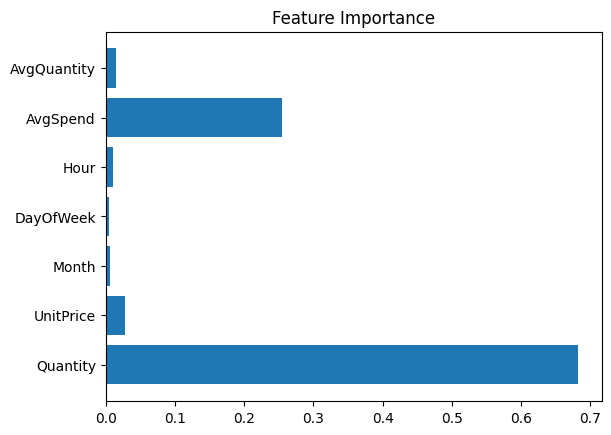

In [33]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [34]:
product_features = df.groupby('StockCode').agg({
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'InvoiceNo': 'count'
}).rename(columns={'InvoiceNo': 'TransactionCount'}).reset_index()

product_features['Failure'] = product_features['Quantity'].apply(lambda x: 1 if x < 50 else 0)

DATA VISUALIZATION

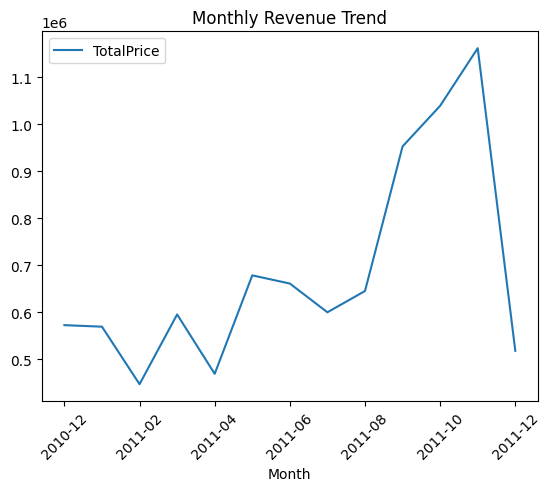

In [35]:
monthly_sales.plot(x='Month', y='TotalPrice', kind='line', title='Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.show()

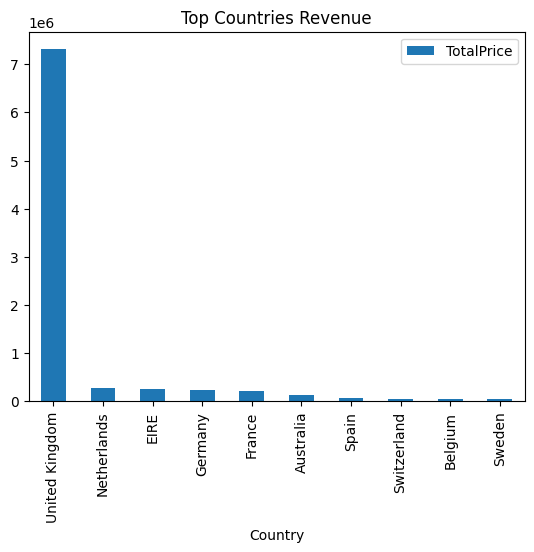

In [36]:
country_revenue.sort_values(by='TotalPrice', ascending=False).head(10)\
    .plot(kind='bar', x='Country', y='TotalPrice', title='Top Countries Revenue')
plt.show()

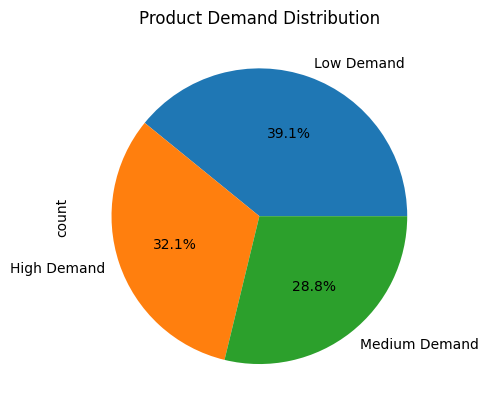

In [37]:
product_demand['DemandCategory'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Product Demand Distribution")
plt.show()

In [38]:
df.to_excel("clean_retail.xlsx", index=False)

In [41]:
df.to_csv("clean_retail.csv", index=False)

In [39]:
product_features.to_csv("product_risk.csv", index=False)

In [40]:
country_revenue.to_csv("country_revenue.csv", index=False)

In [42]:
monthly_sales.to_csv("monthly_sales.csv", index=False)

In [43]:
with pd.ExcelWriter("Retail_AI_Analytics.xlsx") as writer:
    df.to_excel(writer, sheet_name="CleanRetail", index=False)
    product_features.to_excel(writer, sheet_name="ProductRisk", index=False)
    monthly_sales.to_excel(writer, sheet_name="MonthlySales", index=False)
    country_revenue.to_excel(writer, sheet_name="CountryRevenue", index=False)